# Wakefield

In [1]:
import sys
sys.path.append("../..")
import matplotlib
%matplotlib widget
import pprint
pp = pprint.PrettyPrinter(indent=4)
from cavsim2d.cavity import Cavity, EllipticalCavity, Cavities

cavs = Cavities(r'C:\Users\Soske\Documents\git_projects\cavsim2d_simulations')

# define geometry parameters
n_cells = 2
midcell = [62.22, 66.13, 30.22, 23.11, 72, 93.5, 171.20]
midcellvR = [62.22, 66.13, 30.22, 23.11, 80, 93.5, 171.20]
endcell_l = [62.58, 57.54, 17.21, 12, 80, 93.795, 171.20]
endcell_r = [62.58, 57.54, 17.21, 12, 80, 93.795, 171.20]

# create cavity
c3795 = EllipticalCavity(n_cells, midcell, endcell_l,endcell_r, beampipe='both', color='b')
c3795vR = EllipticalCavity(n_cells, midcellvR, endcell_l, endcell_r, beampipe='both', color='r')
cavs.add_cavity([c3795, c3795vR], names=['C3795', 'C3795vR'], plot_labels=['C3795', 'C3795vR'])

wakefield_config = {
    'bunch_length': 25,
    'wakelength': 2,
    'processes': 4,
    'rerun': False,
}
cavs.run_wakefield(wakefield_config)
# pp.pprint(cavs.wakefield_qois)

In [2]:
# cavs[0].plot_animate_wakefield(save=False)

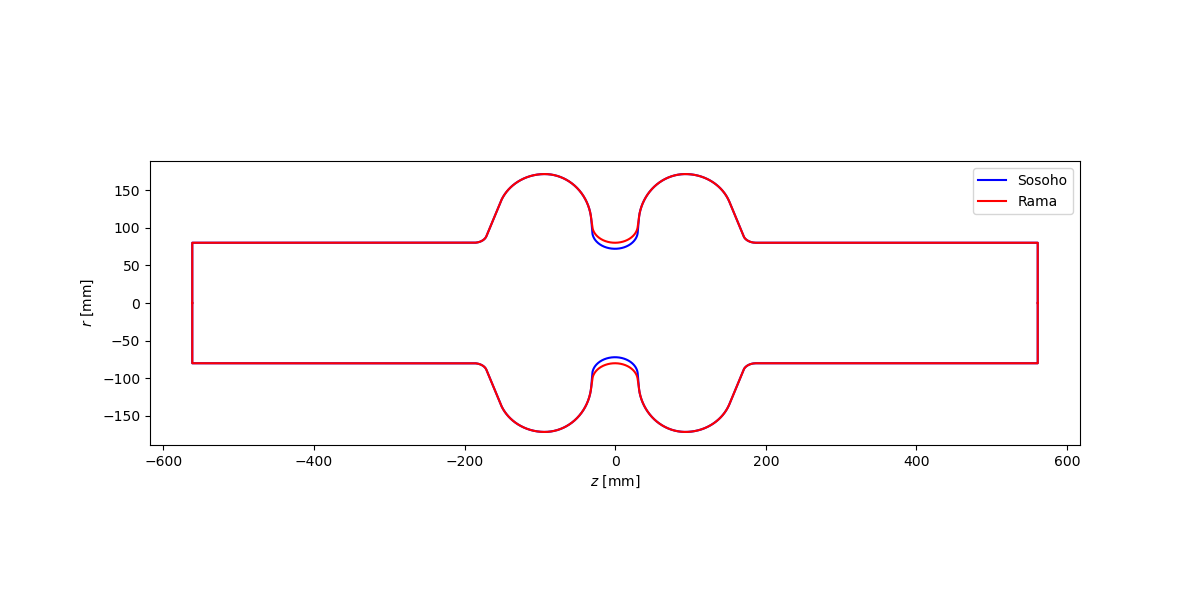

In [3]:
ax = c3795.plot('geometry', label='Sosoho', c='b')
ax = c3795vR.plot('geometry', label='Rama', ax=ax, c='r')

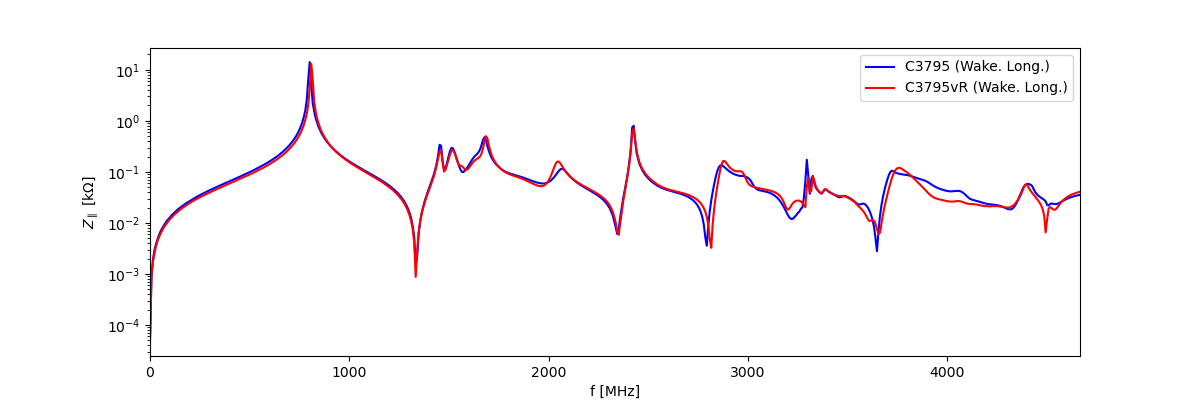

In [9]:
ax = cavs.plot('ZL')
ax.set_yscale('log')

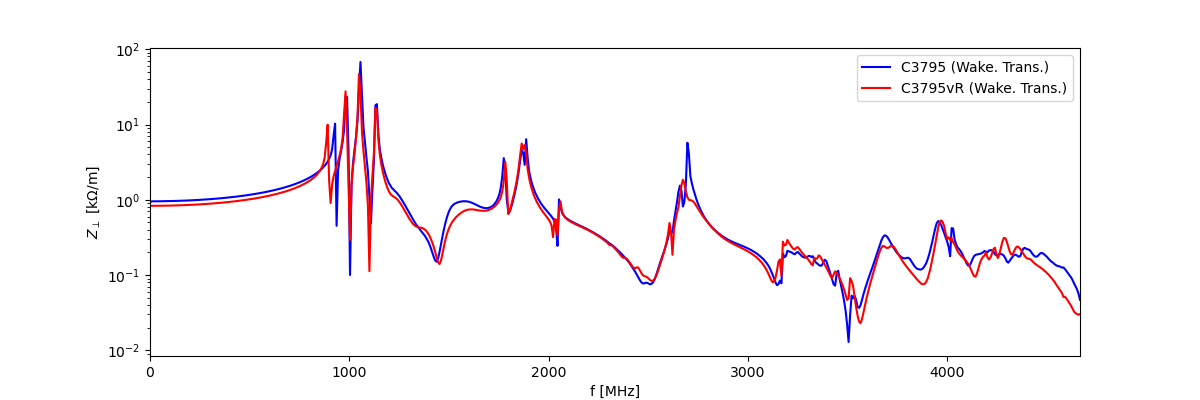

In [10]:
ax = cavs.plot('Zt')
ax.set_yscale('log')

# Wakefield + Operating Points

In [5]:
import sys
sys.path.append("..")
import pprint
pp = pprint.PrettyPrinter(indent=4)
from cavsim2d.cavity import Cavity, EllipticalCavity, Cavities

cavs = Cavities(r'C:\Users\Soske\Documents\git_projects\cavsim2d_simulations')

# define geometry parameters
n_cells = 2
midcell = [42, 42, 12, 19, 35, 57.7, 103.353]  # <- A, B, a, b, Ri, L, Req
endcell_l = [40.34, 40.34, 10, 13.5, 39, 55.716, 103.353]
endcell_r = [42, 42, 9, 12.8, 39, 56.815, 103.353]

# create cavity
tesla = EllipticalCavity(n_cells, midcell, endcell_l,endcell_r, beampipe='none')
cavs.add_cavity([tesla], names=['TESLA'], plot_labels=['TESLA'])

op_points = {
            "Z": {
                "freq [MHz]": 400.79,  # Operating frequency
                "E [GeV]": 45.6,  # <- Beam energy
                "I0 [mA]": 1280,  # <- Beam current
                "V [GV]": 0.12,  # <- Total voltage
                "Eacc [MV/m]": 5.72,  # <- Accelerating field
                "nu_s []": 0.0370,  # <- Synchrotron oscillation tune
                "alpha_p [1e-5]": 2.85,  # <- Momentum compaction factor
                "tau_z [ms]": 354.91,  # <- Longitudinal damping time
                "tau_xy [ms]": 709.82,  # <- Transverse damping time
                "f_rev [kHz]": 3.07,  # <- Revolution frequency
                "beta_xy [m]": 56,  # <- Beta function
                "N_c []": 56,  # <- Number of cavities
                "T [K]": 4.5,  # <- Operating tempereature
                "sigma_SR [mm]": 4.32,  # <- Bunch length
                "sigma_BS [mm]": 15.2,  # <- Bunch length
                "Nb [1e11]": 2.76  # <- Bunch population
            }
}

wakefield_config = {
    'bunch_length': 25,
    'wakelength': 50,
    'processes': 2,
    'rerun': True,
    'operating_points': op_points,
}
cavs.run_wakefield(wakefield_config)
pp.pprint(cavs.wakefield_qois)

UnboundLocalError: cannot access local variable 'all_wakefield_qois' where it is not associated with a value

In [ ]:
cavs.plot_compare_hom_bar('Z_SR_4.32mm')

# Wakefield + Operating Points + UQ

In [ ]:
import sys
sys.path.append("..")
import pprint
pp = pprint.PrettyPrinter(indent=4)
from cavsim2d.cavity import Cavity, EllipticalCavity, Cavities

cavs = Cavities(r'C:\Users\Soske\Documents\git_projects\cavsim2d_simulations')

# define geometry parameters
n_cells = 2
midcell = [42, 42, 12, 19, 35, 57.7, 103.353]  # <- A, B, a, b, Ri, L, Req
endcell_l = [40.34, 40.34, 10, 13.5, 39, 55.716, 103.353]
endcell_r = [42, 42, 9, 12.8, 39, 56.815, 103.353]

# create cavity
tesla = EllipticalCavity(n_cells, midcell, endcell_l,endcell_r, beampipe='none')
cavs.add_cavity([tesla], names=['TESLA'], plot_labels=['TESLA'])

op_points = {
            "Z": {
                "freq [MHz]": 400.79,  # Operating frequency
                "E [GeV]": 45.6,  # <- Beam energy
                "I0 [mA]": 1280,  # <- Beam current
                "V [GV]": 0.12,  # <- Total voltage
                "Eacc [MV/m]": 5.72,  # <- Accelerating field
                "nu_s []": 0.0370,  # <- Synchrotron oscillation tune
                "alpha_p [1e-5]": 2.85,  # <- Momentum compaction factor
                "tau_z [ms]": 354.91,  # <- Longitudinal damping time
                "tau_xy [ms]": 709.82,  # <- Transverse damping time
                "f_rev [kHz]": 3.07,  # <- Revolution frequency
                "beta_xy [m]": 56,  # <- Beta function
                "N_c []": 56,  # <- Number of cavities
                "T [K]": 4.5,  # <- Operating tempereature
                "sigma_SR [mm]": 4.32,  # <- Bunch length
                "sigma_BS [mm]": 15.2,  # <- Bunch length
                "Nb [1e11]": 2.76  # <- Bunch population
            }
}

wakefield_config = {
    'bunch_length': 25,
    'wakelength': 50,
    'processes': 2,
    'rerun': True,
    'operating_points': op_points,
    'uq_config': {
        'variables': ['A'],
        'objectives': [["ZL", [1, 2, 5]], ["ZT", [2, 3, 4]]],
        'delta': [0.05],
        'processes': 4,
        'distribution': 'gaussian',
        # 'method': ['QMC', 'LHS', 1000],
        # 'method': ['QMC', 'Sobol', 1000],
        # 'method': ['Qudrature', 'Gaussian', 1000],
        'method': ['Quadrature', 'Stroud3'],
        # 'method': ['Quadrature', 'Stroud5'],
        # 'gaussian': ['Quadrature', 'Gaussian'],
        # 'from file': ['<file path>', columns],
        'cell_type': 'mid-cell',
        'cell complexity': 'simplecell'
        }
}
cavs.run_wakefield(wakefield_config)
pp.pprint(cavs.wakefield_qois)

In [ ]:
cavs.plot_compare_hom_bar('Z_SR_4.32mm')

# Wakefield (OP) + UQ (+OP)

In [ ]:
import sys
sys.path.append("..")
import pprint
pp = pprint.PrettyPrinter(indent=4)
from cavsim2d.cavity import Cavity, EllipticalCavity, Cavities

cavs = Cavities(r'C:\Users\Soske\Documents\git_projects\cavsim2d_simulations')

# define geometry parameters
n_cells = 2
midcell = [42, 42, 12, 19, 35, 57.7, 103.353]  # <- A, B, a, b, Ri, L, Req
endcell_l = [40.34, 40.34, 10, 13.5, 39, 55.716, 103.353]
endcell_r = [42, 42, 9, 12.8, 39, 56.815, 103.353]

# create cavity
tesla = EllipticalCavity(n_cells, midcell, endcell_l,endcell_r, beampipe='none')
cavs.add_cavity([tesla], names=['TESLA'], plot_labels=['TESLA'])

shape_space = {'reentrant': 
                   {'IC': [53.58, 36.58, 8.08, 9.84, 35, 57.7, 98.27],
                    'OC': [53.58, 36.58, 8.08, 9.84, 35, 57.7, 98.27],
                    'OC_R': [53.58, 36.58, 8.08, 9.84, 35, 57.7, 98.27]
                    }
               }

# create cavity
shape = shape_space['reentrant']
reentrant = EllipticalCavity(n_cells, shape['IC'], shape['OC'], shape['OC_R'], beampipe='both')
cavs.add_cavity([reentrant], names=['Reentrant'], plot_labels=['Re-entrant'])

op_points = {
            "Z": {
                "freq [MHz]": 400.79,  # Operating frequency
                "E [GeV]": 45.6,  # <- Beam energy
                "I0 [mA]": 1280,  # <- Beam current
                "V [GV]": 0.12,  # <- Total voltage
                "Eacc [MV/m]": 5.72,  # <- Accelerating field
                "nu_s []": 0.0370,  # <- Synchrotron oscillation tune
                "alpha_p [1e-5]": 2.85,  # <- Momentum compaction factor
                "tau_z [ms]": 354.91,  # <- Longitudinal damping time
                "tau_xy [ms]": 709.82,  # <- Transverse damping time
                "f_rev [kHz]": 3.07,  # <- Revolution frequency
                "beta_xy [m]": 56,  # <- Beta function
                "N_c []": 56,  # <- Number of cavities
                "T [K]": 4.5,  # <- Operating tempereature
                "sigma_SR [mm]": 4.32,  # <- Bunch length
                "sigma_BS [mm]": 15.2,  # <- Bunch length
                "Nb [1e11]": 2.76  # <- Bunch population
            }
}

wakefield_config = {
    'bunch_length': 25,
    'wakelength': 50,
    'processes': 2,
    'rerun': False,
    'operating_points': op_points,
    'uq_config': {
        'variables': ['A', 'B'],
        'objectives': [["ZL", [1, 2, 5]], ["ZT", [2, 3, 4]], 'k_FM [V/pC]', '|k_loss| [V/pC]', '|k_kick| [V/pC/m]', 'P_HOM [kW]'],
        'delta': [0.05, 0.05],
        'processes': 4,
        'method': ['Stroud3'],
        'cell_type': 'mid-cell',
        'cell complexity': 'simplecell',
        'operating_points': op_points
        }
}
cavs.run_wakefield(wakefield_config)
pp.pprint(cavs.wakefield_qois)

In [ ]:
pp.pprint(cavs.uq_hom_results)

In [ ]:
ax = cavs.plot_compare_wakefield('Z_SR_4.32mm', kind='scatter', uq=True)